In [ ]:
Steps of llms model

s1 -> import libs
s2 -> tokeizer
s3 -> model from pretrained
s4 -> pipeline
s5  -> call pipeline
s6 -> result

In [1]:
# class to wrap HF models inside langChain
from langchain_community.llms import HuggingFacePipeline
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline # load hugging face model

In [ ]:
#load model by using pipeline, task type , model name , temperature is creativity level
hf_pipeline = pipeline(
	task="text-generation", model= "distilgpt2", max_new_tokens=100, temperature=0.7
)

Device set to use cpu


In [ ]:
#allows hf models like normal llms
llm = HuggingFacePipeline(pipeline=hf_pipeline)

In [17]:
prompt = "Hello"

In [ ]:
response = llm.invoke(prompt) # call the model by invoke method uses for execution
print("Model Output: \n")
print(response)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model Output: 

Hello, and I’m sure you’ve seen it.’

While I’m not the only one who’s been told to stop wearing a shirt, I’ve also seen a lot more recently, where the band’s on the side have had plenty of success. But in the past few months, the band’s have been making more music. And we have the band’s right to continue touring.
We’


In [20]:
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

hf_pipeline = pipeline(
	task="text-generation", model='distilgpt2', max_new_tokens=100, temperature=0.7
)


LLM = HuggingFacePipeline(pipeline=hf_pipeline)

prompt = "What is the capital of France?"

response = LLM.invoke(prompt)
print("model op:  \n")
print()

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


model op:  




In [ ]:
| Line                                                       | Explanation                               |
| ---------------------------------------------------------- | ----------------------------------------- |
| `from langchain_community.llms import HuggingFacePipeline` | Wrapper that lets LangChain use HF models |
| `pipeline()`                                               | Loads a HuggingFace model + tokenizer     |
| `task="text-generation"`                                   | Tells HF we want a generative model       |
| `model="distilgpt2"`                                       | Selecting a small free model              |
| `max_new_tokens`                                           | Controls length of generated text         |
| `temperature`                                              | Controls creativity                       |
| `llm = HuggingFacePipeline(...)`                           | Connects HF model to LangChain            |
| `llm.invoke(prompt)`                                       | Generates text using LangChain interface  |


In [3]:
from langchain_community.embeddings import HuggingFaceEmbeddings

In [9]:
embed = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
text = "lang chain is an framework for building ai applications handling llms models "
vector = embed.embed_query(text)
print(len(vector))
print("sample :",vector[:10])

384
sample : [-0.004082140512764454, -0.096311055123806, 0.06358440220355988, -0.041716791689395905, 0.01739496923983097, -0.01571645401418209, -0.020398465916514397, 0.0375191792845726, 0.03297828510403633, -0.005309390369802713]


In [ ]:
| Component               | Meaning                                   |
| ----------------------- | ----------------------------------------- |
| `HuggingFaceEmbeddings` | LangChain wrapper for embedding models    |
| `all-MiniLM-L6-v2`      | Free lightweight model (512-d embeddings) |
| `embed_query()`         | Converts text → vector list               |


In [2]:
#exercise 1
"""I have used the direct model from the first chapter """

from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

hf_pipeline = pipeline(
	task="text-generation", model='distilgpt2',max_new_tokens=100, temperature=0.7
)

LLM = HuggingFacePipeline(pipeline=hf_pipeline)


prompt2 = "Explain machine learning"

resp = LLM.invoke(prompt2)
print(resp)

"""
temperature = 0.1
temperature = 0.9
temperature = 1.2
"""

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Explain machine learning software.




































































































'\ntemperature = 0.1\ntemperature = 0.9\ntemperature = 1.2\n'

In [1]:
from langchain.llms import HuggingFacePipeline
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

model_name = "distilgpt2"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # Required for Falcon  (padding)

# Load model convert the text into tokens, handles vocabulary, handles speical tokens
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="auto"
)

# Create pipeline
text_gen_pipeline = pipeline(
    "text-generation",               # Correct format
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,              # Use max_new_tokens instead of max_length
    temperature=0.7,
    top_p=0.9,
    do_sample=True,
)

# Bind pipeline to LangChain
llm = HuggingFacePipeline(pipeline=text_gen_pipeline)

# Test
text = "Explain the theory of relativity in simple words."
response = llm(text)

print(response)


Device set to use cpu
c:\Users\Sumit\anaconda3\Lib\site-packages\langchain_core\_api\deprecation.py:139: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 0.3. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFacePipeline`.
  warn_deprecated(
c:\Users\Sumit\anaconda3\Lib\site-packages\langchain_core\_api\deprecation.py:139: LangChainDeprecationWarning: The method `BaseLLM.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 0.3.0. Use invoke instead.
  warn_deprecated(


Explain the theory of relativity in simple words. He has been known to be the most influential physicist and physicist in the history of physics. He has been a key proponent of the theory of relativity and in particular the theory of relativity in the 1940s and 1960s.






















































































































































































































In [25]:
"""AutoTokenizer loads the correct tokenizer for the selected model automatically.
	AutoModelForCausalLM loads a modeldesigned for text generations
	pipeline builds simple text-generation pipeline

 """

from langchain.llms import HuggingFacePipeline
from transformers import AutoTokenizer,AutoModelForCausalLM,pipeline

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name) # convert text -> tokens
tokenizer.pad_token = tokenizer.eos_token #padding

model = AutoModelForCausalLM.from_pretrained(
	model_name, trust_remote_code=True, device_map="auto"
)



In [38]:
#pipeline
pipe = pipeline(
	"text-generation",
	model=model,
 tokenizer = tokenizer,
 max_new_tokens=256,
 temperature = 1.2,
 top_p=0.9 ,# nucleus sampling(limited randomness)
 do_sample=True #required for creative/ variable text
)

Device set to use cpu


In [39]:
llm = HuggingFacePipeline(pipeline=pipe)
llm("Explain the theory of relativity in simple words.")


"Explain the theory of relativity in simple words.\n\nAs you will see, the theory of relativity is quite common. The fact that Einstein discovered the law of relativity in 1915, or 'the law of relativity,' seems so close to the truth has no more credibility.\nThe following are an excerpt from the first book:\nWe know that the law of relativity was first established by an astronomer who was trying to investigate the origins and history of quantum mechanics. When Einstein came to know it, he discovered a new way to prove it. We were looking for evidence to substantiate that idea. He also saw how it came from an astrophysicist, known as the Charles C. Cox, who was a physicist who published a book called 'The Quantum Theory of Relativity'. He was intrigued by Einstein's theories and looked into these theories as well. He was so intrigued by the law of relativity that he wanted to prove his theory for himself.\nHe made a huge effort to study the matter, but eventually discovered that the la

In [ ]:
"0.7: 'Explain the theory of relativity in simple words. We know that the theory of relativity is not the same as Einstein‒s theory of relativity.\n\n\nThe reason for the lack of evidence for relativity is that it is not possible to prove that the universe is not as simple as Einstein‒s theory of relativity. We know that the universe is not as simple as Einstein‒s theory of relativity.\nThe proof that the universe is not as simple as Einstein‒s theory of relativity is that it is not as simple as Einstein‒s theory of relativity.\nThe proof that the universe is not as simple as Einstein‒s theory of relativity is that it is not as simple as Einstein‒s theory of relativity.\nThe proof that the universe is not as simple as Einstein‒s theory of relativity is that it is not as simple as Einstein‒s theory of relativity.\nThe proof that the universe is not as simple as Einstein‒s theory of relativity is that it is not as simple as Einstein‒s theory of relativity.\nThe proof that the universe is not as simple as Einstein‒s theory of relativity is that it is not as simple as Einstein‒s theory of relativity.\nThe proof that the universe is not as simple as Einstein'"

"0.1" "'Explain the theory of relativity in simple words.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'"

"0.9" "'Explain the theory of relativity in simple words. But that is not how physicists think. The fact is that relativity does not exist. It does exist.'"

"1.2" "Explain the theory of relativity in simple words.\n\nAs you will see, the theory of relativity is quite common. The fact that Einstein discovered the law of relativity in 1915, or 'the law of relativity,' seems so close to the truth has no more credibility.\nThe following are an excerpt from the first book:\nWe know that the law of relativity was first established by an astronomer who was trying to investigate the origins and history of quantum mechanics. When Einstein came to know it, he discovered a new way to prove it. We were looking for evidence to substantiate that idea. He also saw how it came from an astrophysicist, known as the Charles C. Cox, who was a physicist who published a book called 'The Quantum Theory of Relativity'. He was intrigued by Einstein's theories and looked into these theories as well. He was so intrigued by the law of relativity that he wanted to prove his theory for himself.\nHe made a huge effort to study the matter, but eventually discovered that the law of relativity was a mystery and no one could ever know it. In his final paper on relativity a man, he said that Einstein never knew what the law of relativity was.\nHe published a number of papers at the time of publication, including a number of interesting new discoveries including a"

In [ ]:
| Model Class                            | When to Use                           | Pipeline                       |
| -------------------------------------- | ------------------------------------- | ------------------------------ | 
| **AutoModelForSeq2SeqLM**              | Translation, summarization, text2text | `text2text-generation`         | done
| **AutoModelForCausalLM**               | Text generation, chat models          | `text-generation`              | done
| **AutoModelForMaskedLM**               | Mask filling                          | `fill-mask`                    | done
| **AutoModelForSequenceClassification** | Sentiment, text classification        | `text-classification`          | done    2
| **AutoModelForTokenClassification**    | NER                                   | `token-classification`         | done     2
| **AutoModelForQuestionAnswering**      | QA with context                       | `question-answering`           | done     2
| **AutoModelForImageClassification**    | Image labels                          | `image-classification`         | done   3
| **AutoModelForObjectDetection**        | Bounding boxes                        | `object-detection`             | done   3  
| **AutoModelForImageSegmentation**      | Segmentation                          | `image-segmentation`           | done   3
| **AutoModelForVision2Seq**             | Image captioning                      | `image-to-text`                | done   3==
| **AutoModelForAudioClassification**    | Audio labels                          | `audio-classification`         | done 
| **AutoModelForSpeechSeq2Seq**          | Speech-to-text                        | `automatic-speech-recognition` | done


In [12]:
# Text 2 Text generation : Summary ,translation and text2text generation

from langchain.llms import HuggingFacePipeline
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
pipe = pipeline("text2text-generation", model=model,tokenizer=tokenizer)
llms = HuggingFacePipeline(pipeline=pipe)

#Summary
result = llms.invoke("summarize: ChatGPT is an AI developed by OpenAI. It helps users generate human-like text.")
print(result)

# translation
translation = llms.invoke("translate English to French: I love programming.")
print(translation)

# text2 text
t2t_generation = llms.invoke("I love coffee")
t2t_generation

Device set to use cpu


ChatGPT is an AI developed by OpenAI . it helps users generate human-like text
Je suis en amour de la programmation.


'i love coffee.'

In [ ]:
3] fill mask 
- predict missing words
- sentence classification fine tunning
- NER text classification 
- semantic  similarity
- mebeding 

customize filler maask model 
| Customization         | Code Provided |
| --------------------- | ------------- |
| Limit results         | ✔             |
| Correct mask token    | ✔             |
| Best score            | ✔             |
| Limit candidates      | ✔             |
| POS filtering         | ✔             |
| Clean token output    | ✔             |
| True softmax scoring  | ✔             |
| LangChain integration | ✔             |

In [44]:
# missing values filler with words
from transformers import pipeline

pipe = pipeline("fill-mask", model="albert-base-v2")

result = pipe("Chagpt is very [MASK] tool.")
best = max(result, key=lambda x: x['score'])
print(best)
result

Some weights of the model checkpoint at albert-base-v2 were not used when initializing AlbertForMaskedLM: ['albert.pooler.bias', 'albert.pooler.weight']
- This IS expected if you are initializing AlbertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing AlbertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


{'score': 0.1266738772392273, 'token': 4811, 'token_str': 'useful', 'sequence': 'chagpt is very useful tool.'}


[{'score': 0.1266738772392273,
  'token': 4811,
  'token_str': 'useful',
  'sequence': 'chagpt is very useful tool.'},
 {'score': 0.044033993035554886,
  'token': 2177,
  'token_str': 'powerful',
  'sequence': 'chagpt is very powerful tool.'},
 {'score': 0.03482309356331825,
  'token': 5940,
  'token_str': 'valuable',
  'sequence': 'chagpt is very valuable tool.'},
 {'score': 0.03295503929257393,
  'token': 3140,
  'token_str': 'effective',
  'sequence': 'chagpt is very effective tool.'},
 {'score': 0.030984532088041306,
  'token': 1935,
  'token_str': 'simple',
  'sequence': 'chagpt is very simple tool.'}]

In [47]:
from transformers import pipeline

data = [
    ("I love this product, it works amazingly well!"),
    ("This is the best experience I've ever had."),
    ("Absolutely fantastic service and quick response."),
    
    ("The product is okay, nothing special."),
    ("I feel indifferent about the new update."),
    ("It's neither good nor bad, just average."),
    
    ("I hate this product, it broke in one day."),
    ("Worst customer service ever."),
    ("Very disappointed and frustrated!"),
]

sentiment = pipeline('sentiment-analysis', model="distilbert-base-uncased-finetuned-sst-2-english")

result = sentiment(data)

for i in range(len(result)):
    print({result[i]['label']})

Device set to use cpu


{'POSITIVE'}
{'POSITIVE'}
{'POSITIVE'}
{'NEGATIVE'}
{'NEGATIVE'}
{'NEGATIVE'}
{'NEGATIVE'}
{'NEGATIVE'}
{'NEGATIVE'}


In [1]:
pip install sounddevice

Note: you may need to restart the kernel to use updated packages.


In [3]:
from transformers import AutoProcessor, AutoModel
import torch, sounddevice as sd

processor = AutoProcessor.from_pretrained("facebook/mms-tts-eng")
model = AutoModel.from_pretrained("facebook/mms-tts-eng")

inputs = processor("artifical intelligence refers to a range of cognitive abilities that are developed during early childhood and function in everyday life.", return_tensors="pt")

with torch.no_grad():
    speech = model(**inputs).waveform
    

sd.play(speech[0].numpy(), samplerate=16000, blocking=True)
sd.wait()

Exception ignored from cffi callback <function _StreamBase.__init__.<locals>.finished_callback_wrapper at 0x00000243649AB880>:
Traceback (most recent call last):
  File "C:\Users\Sumit\anaconda3\Lib\site-packages\sounddevice.py", line 940, in finished_callback_wrapper
    return finished_callback()
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Sumit\anaconda3\Lib\site-packages\sounddevice.py", line 2653, in finished_callback
    del self.out
        ^^^^^^^^
AttributeError: '_CallbackContext' object has no attribute 'out'


In [24]:
from langchain.llms import HuggingFacePipeline
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen1.5-0.5B-Chat"

model = AutoModelForCausalLM.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
pipe = pipeline('text-generation', model=model, tokenizer=tokenizer)
llm = HuggingFacePipeline(pipeline=pipe)

result = llm.invoke("artifical intelligence")
print(result)

Device set to use cpu


artifical intelligence can be trained to help a person in their career


In [3]:
#automatic-speech-recognition

from transformers import AutoProcessor, AutoModel
import torch 
import soundfile as sf

model_name = "facebook/mms-tts-eng"
process = AutoProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

text = "artifical intelligence refers to a range of cognitive abilities that are developed during early childhood and function in everyday life."
inputs =  process(text=text, return_tensors="pt")

#generate speech
with torch.no_grad():
    output = model(**inputs)
    speech = output.waveform
    
speech_np = speech.squeeze().cpu().numpy()

sf.write(file="audio1.wav", data=speech_np, samplerate=16000)
print("audio saved")

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

audio saved


In [ ]:
import sounddevice as sd 
import soundfile as sf

audio,sr = sf.read("audio1.wav")
sd.play(audio,sr)
sd.wait()

In [5]:
#audio classification model 
%pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)

   ------------- -------------------------- 1/3 [audioread]
   -------------------------- ------------- 2/3 [librosa]
   -------------------------- ------------- 2/3 [librosa]
   -------------------------- ------------- 2/3 [librosa]
   ---------------------------------------- 3/3 [librosa]

Note: you may need to restart the kernel to use updated packages.


In [7]:
#audio-classification
import librosa 
import torch 
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

model_name = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
model = AutoModelForAudioClassification.from_pretrained(model_name)


audio_path = "audio1.wav"
audio , sr = librosa.load(audio_path, sr=16000)

inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits
    
    
probs = torch.softmax(logits, dim=-1)

predicted_id = torch.argmax(probs, dim=-1).item()
label = model.config.id2label[predicted_id]
confidence = probs[0][predicted_id].item()

print("predicted label: ",label)
print("Confidence: ",round(confidence, 3))

predicted label:  Speech
Confidence:  0.814


In [13]:
#text-classification
import torch 
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline


model_name = "SamLowe/roberta-base-go_emotions"
toeknizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
pipe = pipeline("text-classification",model=model,tokenizer=toeknizer)


text = "I really love this product. it works perfectly!"

result = pipe(text)
print(result)

Device set to use cpu


[{'label': 'love', 'score': 0.8496888875961304}]


In [40]:
#token classification 
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

mode_name = "SamLowe/roberta-base-go_emotions"
token = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)
pipe = pipeline("token-classification", model=model,tokenizer=token, aggregation_strategy="simple")

text = "My name is Sumit and I work at rbi sector of gvoverment job "

result = pipe(text)
for entity in result:
    print(entity)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'entity_group': 'LABEL_1', 'score': 0.5469656, 'word': 'my name is', 'start': 0, 'end': 10}
{'entity_group': 'LABEL_0', 'score': 0.5720323, 'word': 'sum', 'start': 11, 'end': 14}
{'entity_group': 'LABEL_1', 'score': 0.5812353, 'word': '##it and i work at rbi sector of gvo', 'start': 14, 'end': 48}
{'entity_group': 'LABEL_0', 'score': 0.5180912, 'word': '##ver', 'start': 48, 'end': 51}
{'entity_group': 'LABEL_1', 'score': 0.55618, 'word': '##ment job', 'start': 51, 'end': 59}


In [34]:
#question-answering 
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline
model_name = "prajjwal1/bert-tiny"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)

context = """ 
Artifical Intelligence is the  simulation of human intelligence  in machine that  
are programmed to think and learn. 
"""

question = "what is artifical intelligence"

result = pipe(question=question,context=context)
print(result)

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


{'score': 0.003440719097852707, 'start': 103, 'end': 119, 'answer': 'think and learn.'}


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Predicted label: strawberry
confidence:  0.996


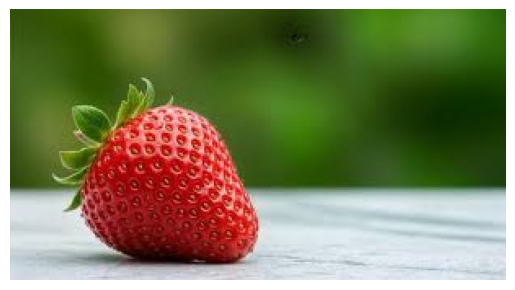

In [16]:
#image classification
import torch 
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

#image 1
image = Image.open("image.jpg").convert("RGB")
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    

logits = outputs.logits  
probs = torch.softmax(logits, dim=-1)

predicted_id = probs.argmax().item()
label = model.config.id2label[predicted_id]
confidence = probs[0][predicted_id].item()

print("Predicted label:",label)
print("confidence: ", round(confidence,3))

#show image
plt.imshow(image)
plt.axis("off")
plt.show()

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.48.2"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_rang

[{'generated_text': 'a woman taking a picture of herself in a mirror '}]


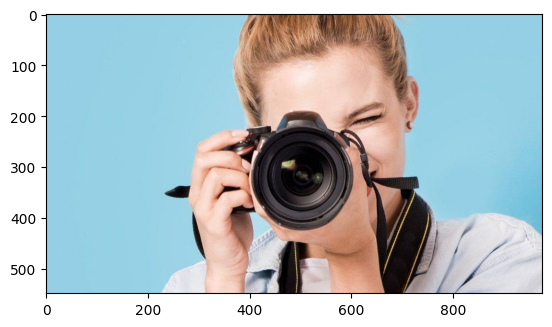

In [4]:
# image - to - text 
from transformers import pipeline, AutoImageProcessor
from PIL import Image
import matplotlib.pyplot as plt 

processor = AutoImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
captioner = pipeline("image-to-text", model="nlpconnect/vit-gpt2-image-captioning", processor=processor)
image = Image.open("image2.jpg")
result = captioner(image)
print(result)

plt.imshow(image)
plt.show()

Some weights of the model checkpoint at facebook/detr-resnet-50-panoptic were not used when initializing DetrForSegmentation: ['detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForSegmentation from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForSegmentation from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


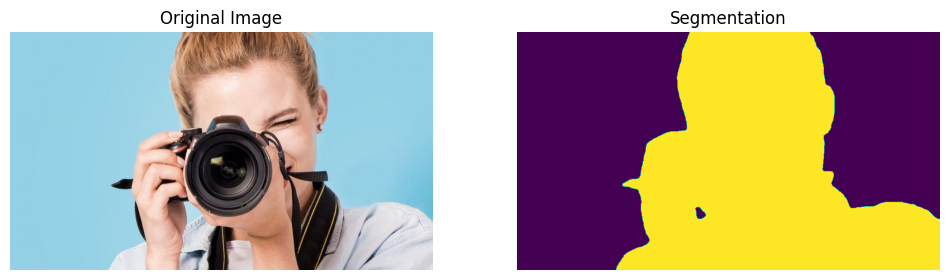

In [21]:
#image segmentation
from transformers import DetrImageProcessor,DetrForSegmentation
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

model_name = "facebook/detr-resnet-50-panoptic"
image = Image.open("image2.jpg").convert("RGB")

processor = DetrImageProcessor.from_pretrained(model_name)
model = DetrForSegmentation.from_pretrained(model_name)

inputs = processor(images=image, return_tensors="pt")
with torch.no_grad():
    output = model(**inputs)

segmentation = processor.post_process_panoptic_segmentation(output, target_sizes=[image.size[::-1]])[0]
segmentation_map = segmentation['segmentation'].cpu().numpy()


plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmentation_map)
plt.title("Segmentation")
plt.axis("off")

plt.show()

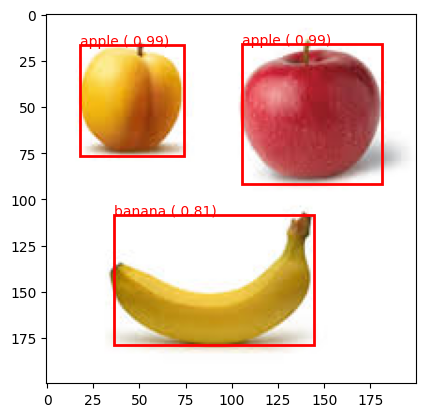

In [8]:
#object detection 
import torch 
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image = Image.open("image4.jpg").convert("RGB")

model_name = "hustvl/yolos-tiny"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForObjectDetection.from_pretrained(model_name)

inputs = processor(images=image, return_tensors='pt')

with torch.no_grad():
    output = model(**inputs)
    
target_sizes = torch.tensor([image.size[::-1]])
results = processor.post_process_object_detection(output, threshold=0.5, target_sizes=target_sizes)[0]

fig,ax = plt.subplots(1)
ax.imshow(image)

for score, label, box in zip(
    results["scores"], results['labels'], results['boxes']
):
    box = box.tolist()
    x,y,x2,y2 = box 
    rect = patches.Rectangle(
        (x,y), x2-x, y2-y,linewidth=2, edgecolor="red", facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x,y, f"{model.config.id2label[label.item()]} ({score: .2f})", color='red')
    

plt.show()

question:  Which fruits are there in the image
answer: apple and banana


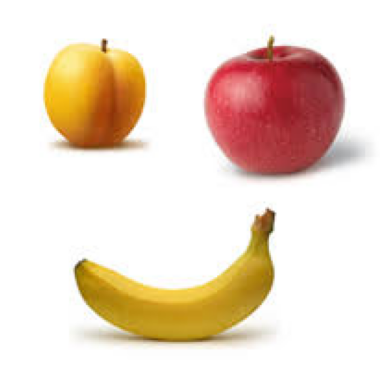

In [16]:
import torch 
from PIL import Image 
from transformers import AutoProcessor, ViltForQuestionAnswering
import matplotlib.pyplot as plt

model_name = "dandelin/vilt-b32-finetuned-vqa"
processor = AutoProcessor.from_pretrained(model_name)
model = ViltForQuestionAnswering.from_pretrained(model_name)

image = Image.open("image4.jpg").convert("RGB")

question = "Which fruits are there in the image"

inputs = processor(image, question, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    
logits = outputs.logits
predicted_id = logits.argmax(-1).item()
answer = model.config.id2label[predicted_id]

plt.imshow(image)
plt.axis('off')


print("question: ", question)
print("answer:", answer)